# Métodos de agrupamiento

## Algoritmos de agrupamiento por k-medias

In [1]:
import pandas as pd
from google.colab import files

# Métodos de agrupamiento
# Algoritmos de agrupamiento por k-medias.

# Cargue y depuración del conjunto de datos
uploaded = files.upload()
datos = pd.read_excel("Trabajadores.xlsx")

datos.iloc[:, [0, 2, 7, 11]] = datos.iloc[:, [0, 2, 7, 11]].astype("category")

datos["Escolaridad"] = pd.Categorical(
    datos["Escolaridad"],
    categories=["Técnico", "Pregrado", "Posgrado"],
    ordered=True
)

datos["Estrato"] = datos["Estrato"].astype("string").str.strip().replace({
    "1.0": "1",
    "2.0": "2",
    "3.0": "3"
})

datos["Estrato"] = pd.Categorical(
    datos["Estrato"],
    categories=["1", "2", "3", "4+"],
    ordered=True
)

datos["Situación"] = pd.Categorical(
    datos["Situación"],
    categories=["Difícil", "Regular", "Buena"],
    ordered=True
)

print(datos.head())
print(datos.shape)

Saving Trabajadores.xlsx to Trabajadores.xlsx
  Sexo  Edad  Estado  Hijos Escolaridad Estrato  Ingresos Ayuda  Dependen  \
0    F    45  Casado      2    Posgrado      4+     8.800    No         3   
1    M    36  Casado      2    Pregrado       3     5.920    No         1   
2    M    61  Casado      3     Técnico       2     2.256    Sí         2   
3    F    40   Viudo      2    Posgrado       2     5.706    No         2   
4    F    49  Casado      3    Posgrado      4+     9.450    Sí         1   

   Egresos Situación      Créditos  Conocimiento  
0    8.410     Buena  Sin Créditos         0.249  
1    3.915     Buena      Vigentes         0.491  
2    2.390   Difícil      Vigentes         0.449  
3    3.480     Buena      Vigentes         0.506  
4    2.900     Buena      Vigentes         0.675  
(168, 13)


In [2]:
from sklearn.cluster import KMeans

# Métodos basados en centroides

# Variables numéricas

# Agrupamiento por k-medias
k = 2 # número de grupos (se debe determinar)

X = datos.select_dtypes(include="number")
X = (X - X.mean()) / X.std(ddof=1)

ag_km = KMeans(
    n_clusters=k,
    max_iter=30,
    n_init=10,
    algorithm="lloyd" # no existe la opción Hartigan-Wong
).fit(X)

In [3]:
# Asignación de los individuos a los grupos
grupos = ag_km.labels_ + 1

print(grupos)
display(pd.concat([pd.DataFrame({"grupos": grupos}, index=datos.index), datos], axis=1).head(10))

[1 1 1 1 1 1 1 1 2 1 1 2 2 1 1 1 2 2 2 2 2 2 1 2 2 2 1 2 1 2 1 2 2 2 2 2 1
 1 2 2 1 2 2 2 1 2 2 2 2 2 1 2 2 2 2 2 1 1 2 2 1 2 2 2 2 2 1 2 2 2 2 1 1 2
 2 1 2 1 1 1 1 2 2 2 2 2 1 1 1 2 1 2 1 2 1 1 2 1 2 1 2 1 1 1 2 1 2 2 2 2 2
 2 1 1 2 2 1 1 1 2 2 2 2 2 2 2 2 2 1 1 2 1 2 2 1 2 2 2 1 1 1 1 2 2 2 1 2 1
 1 1 1 2 1 2 1 1 1 1 1 1 1 2 2 2 2 2 2 1]


,grupos,Sexo,Edad,Estado,Hijos,Escolaridad,Estrato,Ingresos,Ayuda,Dependen,Egresos,Situación,Créditos,Conocimiento
0,1,F,45,Casado,2,Posgrado,4+,8.800,No,3,8.410,Buena,Sin Créditos,0.249
1,1,M,36,Casado,2,Pregrado,3,5.920,No,1,3.915,Buena,Vigentes,0.491
2,1,M,61,Casado,3,Técnico,2,2.256,Sí,2,2.390,Difícil,Vigentes,0.449
3,1,F,40,Viudo,2,Posgrado,2,5.706,No,2,3.480,Buena,Vigentes,0.506
4,1,F,49,Casado,3,Posgrado,4+,9.450,Sí,1,2.900,Buena,Vigentes,0.675
5,1,F,48,Separado,2,Pregrado,2,5.835,No,1,2.755,Regular,Vigentes,0.549
6,1,M,34,Casado,2,Pregrado,3,5.700,No,3,3.770,Regular,Vigentes,0.449
7,1,F,49,Unión Libre,2,Posgrado,3,6.246,No,3,4.250,Buena,En Mora,0.670
8,2,M,29,Soltero,0,Posgrado,3,4.500,No,3,3.190,Buena,Vigentes,0.395
9,1,F,39,Unión Libre,1,Pregrado,3,4.650,No,3,2.610,Regular,En Mora,0.549


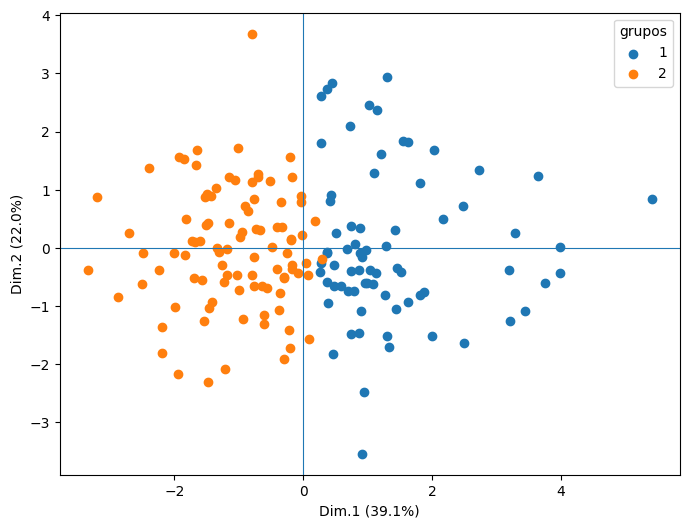

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Representación de los grupos mediante un ACP
acp = PCA(n_components=2)
coord = acp.fit_transform(X)

acp_grupos = pd.DataFrame(
    coord,
    columns=["Dim.1", "Dim.2"],
    index=datos.index
)

acp_grupos["grupos"] = grupos.astype(str)

plt.figure(figsize=(8, 6))

for g in sorted(acp_grupos["grupos"].unique()):
    temp = acp_grupos[acp_grupos["grupos"] == g]
    plt.scatter(temp["Dim.1"], temp["Dim.2"], label=g)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel(f"Dim.1 ({acp.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"Dim.2 ({acp.explained_variance_ratio_[1] * 100:.1f}%)")
plt.legend(title="grupos")
plt.show()

## Validación

In [6]:
from sklearn.metrics import pairwise_distances, silhouette_score
import numpy as np

# Validación

# Distancia
D = pairwise_distances(X, metric="euclidean")
np.fill_diagonal(D, 0)

# Validación interna
val = silhouette_score(D, grupos, metric="precomputed")

val # Silhouette promedio

np.float64(0.23132711212743096)

In [7]:
# Dunn
clusters = np.unique(grupos)

diametros = []
separaciones = []

for g in clusters:
    idx = grupos == g
    diametros.append(D[np.ix_(idx, idx)].max())

for i, g1 in enumerate(clusters):
    for g2 in clusters[(i + 1):]:
        idx1 = grupos == g1
        idx2 = grupos == g2
        separaciones.append(D[np.ix_(idx1, idx2)].min())

val = min(separaciones) / max(diametros)

val # Dunn

np.float64(0.085227526139679)

In [8]:
from sklearn.metrics import calinski_harabasz_score

val = calinski_harabasz_score(X, grupos)

val # Calinski-Harabasz

np.float64(55.161616510020096)

In [9]:
from sklearn.metrics import davies_bouldin_score

val = davies_bouldin_score(X, grupos)

val # Davies-Bouldin

np.float64(1.618450016085548)

In [10]:
# Connectivity
neighbSize = 10

D_aux = D.copy()
np.fill_diagonal(D_aux, np.inf)

vecinos = np.argsort(D_aux, axis=1)[:, :neighbSize]

val = 0

for i in range(D_aux.shape[0]):
    for j in range(neighbSize):
        if grupos[i] != grupos[vecinos[i, j]]:
            val += 1 / (j + 1)

val # Connectivity

52.44682539682549

In [11]:
# Gap statistic
np.random.seed(123)

B = 100
val_gap = []

for kk in range(1, k + 1):
    km = KMeans(
        n_clusters=kk,
        max_iter=30,
        n_init=10,
        algorithm="lloyd",
        random_state=123
    ).fit(X)

    Wk = km.inertia_

    Wkb = []

    for b in range(B):
        Xb = pd.DataFrame(
            np.random.uniform(
                low=X.min().to_numpy(),
                high=X.max().to_numpy(),
                size=X.shape
            ),
            columns=X.columns
        )

        km_b = KMeans(
            n_clusters=kk,
            max_iter=30,
            n_init=10,
            algorithm="lloyd",
            random_state=123 + b
        ).fit(Xb)

        Wkb.append(km_b.inertia_)

    val_gap.append(np.mean(np.log(Wkb)) - np.log(Wk))

val = val_gap[k - 1]

val # Gap statistic

np.float64(0.8285160766467712)

In [12]:
# APN
apn_vals = []

for col in X.columns:
    X_menos = X.drop(columns=col)

    km_menos = KMeans(
        n_clusters=k,
        max_iter=30,
        n_init=10,
        algorithm="lloyd",
        random_state=123
    ).fit(X_menos)

    grupos_menos = km_menos.labels_ + 1

    apn_col = 0

    for i in range(X.shape[0]):
        grupo_original = np.where(grupos == grupos[i])[0]
        grupo_menos = np.where(grupos_menos == grupos_menos[i])[0]

        apn_col += 1 - len(np.intersect1d(grupo_original, grupo_menos)) / len(grupo_original)

    apn_vals.append(apn_col / X.shape[0])

val = np.mean(apn_vals)

val # APN

np.float64(0.1461553426946362)

In [13]:
# FOM
fom_vals = []

for col in X.columns:
    X_menos = X.drop(columns=col)

    km_menos = KMeans(
        n_clusters=k,
        max_iter=30,
        n_init=10,
        algorithm="lloyd",
        random_state=123
    ).fit(X_menos)

    grupos_menos = km_menos.labels_ + 1

    suma = 0

    for g in np.unique(grupos_menos):
        idx = grupos_menos == g
        xg = X.loc[idx, col]
        suma += ((xg - xg.mean()) ** 2).sum()

    fom_vals.append(np.sqrt(suma / X.shape[0]))

val = np.mean(fom_vals)

val # FOM

np.float64(0.9437126385306666)

In [14]:
# Prediction strength
np.random.seed(123)

M = 100
pred_vals = []

for m in range(M):
    idx = np.random.permutation(X.shape[0])
    idx_1 = idx[:X.shape[0] // 2]
    idx_2 = idx[X.shape[0] // 2:]

    X_1 = X.iloc[idx_1]
    X_2 = X.iloc[idx_2]

    km_1 = KMeans(
        n_clusters=k,
        max_iter=30,
        n_init=10,
        algorithm="lloyd",
        random_state=123
    ).fit(X_1)

    km_2 = KMeans(
        n_clusters=k,
        max_iter=30,
        n_init=10,
        algorithm="lloyd",
        random_state=123
    ).fit(X_2)

    grupos_2 = km_2.labels_ + 1

    dist_cent = pairwise_distances(X_2, km_1.cluster_centers_, metric="euclidean")
    grupos_pred = dist_cent.argmin(axis=1) + 1

    ps_k = []

    for g in np.unique(grupos_pred):
        idx_g = np.where(grupos_pred == g)[0]

        if len(idx_g) > 1:
            total = 0
            coinciden = 0

            for i in range(len(idx_g)):
                for j in range(i + 1, len(idx_g)):
                    total += 1

                    if grupos_2[idx_g[i]] == grupos_2[idx_g[j]]:
                        coinciden += 1

            ps_k.append(coinciden / total)

    pred_vals.append(min(ps_k))

val = np.mean(pred_vals)

val # Prediction strength

np.float64(0.7266462555916562)

In [16]:
# Bootstrap Jaccard stability
np.random.seed(123)

B = 100
grupos_array = np.asarray(grupos)
clusters_original = np.unique(grupos_array)

original_clusters = {
    g: set(np.where(grupos_array == g)[0])
    for g in clusters_original
}

boot_jaccard = {
    g: []
    for g in clusters_original
}

for b in range(B):
    idx_boot = np.random.choice(np.arange(X.shape[0]), size=X.shape[0], replace=True)
    X_boot = X.iloc[idx_boot]

    km_boot = KMeans(
        n_clusters=k,
        max_iter=30,
        n_init=10,
        algorithm="lloyd",
        random_state=123 + b
    ).fit(X_boot)

    grupos_boot = km_boot.labels_ + 1

    for g in clusters_original:
        original = original_clusters[g]
        jaccards = []

        for gb in np.unique(grupos_boot):
            boot_cluster = set(idx_boot[grupos_boot == gb])

            interseccion = len(original.intersection(boot_cluster))
            union = len(original.union(boot_cluster))

            jaccards.append(interseccion / union)

        boot_jaccard[g].append(max(jaccards))

bootmean = pd.Series(
    {
        g: np.mean(boot_jaccard[g])
        for g in clusters_original
    },
    name="Bootstrap Jaccard stability"
)

bootmean
bootmean.mean()

np.float64(0.5765017917555806)

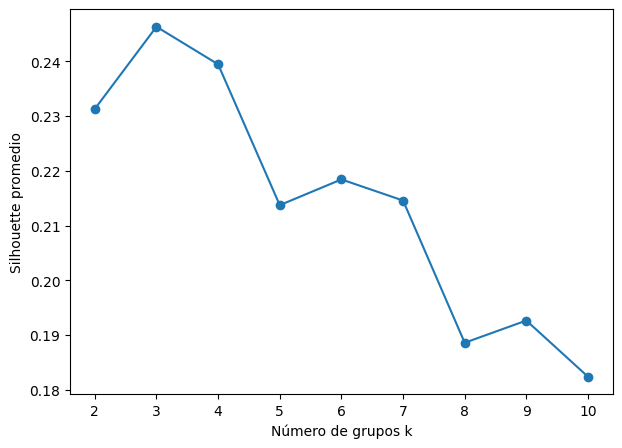

In [17]:
# Gráficas

# Silhouette o Gap
K_max = 10
val_sil = []

for kk in range(2, K_max + 1):
    km = KMeans(
        n_clusters=kk,
        max_iter=30,
        n_init=10,
        algorithm="lloyd"
    ).fit(X)

    grupos_k = km.labels_ + 1

    val_sil.append(
        silhouette_score(X, grupos_k, metric="euclidean")
    )

plt.figure(figsize=(7, 5))
plt.plot(range(2, K_max + 1), val_sil, marker="o")
plt.xlabel("Número de grupos k")
plt.ylabel("Silhouette promedio")
plt.show()

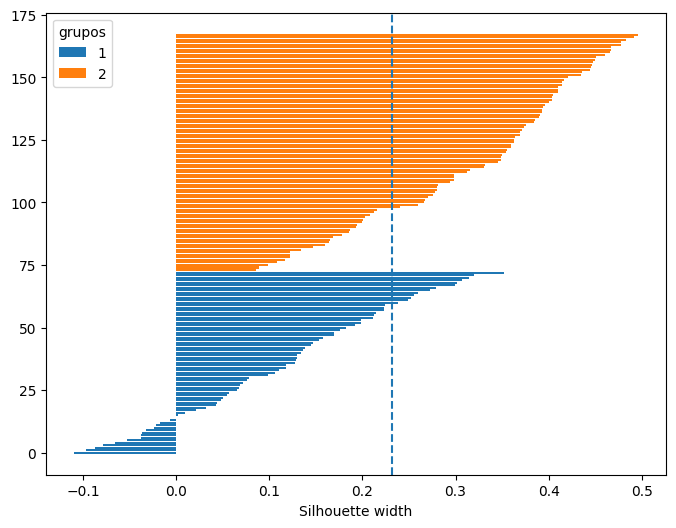

In [18]:
from sklearn.metrics import silhouette_samples

sil = silhouette_samples(D, grupos, metric="precomputed") # Silhouette por individuo

sil_df = pd.DataFrame({
    "sil_width": sil,
    "grupos": grupos
})

sil_df = sil_df.sort_values(["grupos", "sil_width"]).reset_index(drop=True)

plt.figure(figsize=(8, 6))

y_lower = 0

for g in sorted(sil_df["grupos"].unique()):
    vals = sil_df.loc[sil_df["grupos"] == g, "sil_width"].to_numpy()
    y_upper = y_lower + len(vals)

    plt.barh(
        range(y_lower, y_upper),
        vals,
        edgecolor="none",
        label=str(g)
    )

    y_lower = y_upper

plt.axvline(sil.mean(), linestyle="--")
plt.xlabel("Silhouette width")
plt.ylabel("")
plt.legend(title="grupos")
plt.show()

## hk-means

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster

###########

# hk-means
ag_hc = linkage(X, method="ward", metric="euclidean")
grupos_hc = fcluster(ag_hc, t=k, criterion="maxclust")

centros_ini = pd.DataFrame(X).groupby(grupos_hc).mean().to_numpy()

ag_hkm = KMeans(
    n_clusters=k,
    init=centros_ini,
    n_init=1,
    max_iter=30,
    algorithm="lloyd"
).fit(X)

grupos = ag_hkm.labels_ + 1

grupos

## k-medoides

In [23]:
# k-medoides
np.random.seed(123)

D_kmed = pairwise_distances(X, metric="euclidean")
np.fill_diagonal(D_kmed, 0)

n = D_kmed.shape[0]

medoides = [np.argmin(D_kmed.sum(axis=1))]

while len(medoides) < k:
    dist_actual = D_kmed[:, medoides].min(axis=1)
    candidatos = [i for i in range(n) if i not in medoides]

    costos = [
        np.minimum(dist_actual, D_kmed[:, c]).sum()
        for c in candidatos
    ]

    medoides.append(candidatos[np.argmin(costos)])

for it in range(30):
    grupos_temp = np.argmin(D_kmed[:, medoides], axis=1)
    costo_actual = D_kmed[np.arange(n), np.array(medoides)[grupos_temp]].sum()

    mejor_costo = costo_actual
    mejores_medoides = medoides.copy()

    for pos_m, m in enumerate(medoides):
        candidatos = [i for i in range(n) if i not in medoides]

        for c in candidatos:
            medoides_cand = medoides.copy()
            medoides_cand[pos_m] = c

            grupos_cand = np.argmin(D_kmed[:, medoides_cand], axis=1)
            costo_cand = D_kmed[np.arange(n), np.array(medoides_cand)[grupos_cand]].sum()

            if costo_cand < mejor_costo:
                mejor_costo = costo_cand
                mejores_medoides = medoides_cand.copy()

    if mejor_costo < costo_actual:
        medoides = mejores_medoides.copy()
    else:
        break

grupos = np.argmin(D_kmed[:, medoides], axis=1) + 1

ag_kmed = {
    "medoides": medoides,
    "clustering": grupos,
    "objective": mejor_costo
}

grupos

array([2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1,
       2, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1,
       2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1, 1, 1,
       2, 1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2,
       2, 1, 1, 1, 2, 1, 2, 2, 1, 2, 1, 2, 1, 2, 2, 2, 1, 2, 1, 1, 1, 1,
       2, 1, 2, 2, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 1, 2,
       1, 1, 2, 2, 1, 2, 2, 2, 2, 2, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 1, 1,
       2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 1, 1, 2])

## Agrupamiento difuso

In [22]:
!pip install scikit-fuzzy
import skfuzzy as fuzz

##########

# Fuzzy k-means
np.random.seed(123)

ag_fkm = fuzz.cluster.cmeans(
    data=X.T,
    c=k,
    m=2,
    error=1e-5,
    maxiter=30,
    seed=123
)

membership = pd.DataFrame(
    ag_fkm[1].T,
    columns=[f"Grupo {i}" for i in range(1, k + 1)],
    index=datos.index
)

# Asignación a los grupos
membership # grados de pertenencia

grupos = membership.to_numpy().argmax(axis=1) + 1
grupos # grupos duros

array([2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1,
       2, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1,
       2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1, 1, 1,
       2, 1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2,
       2, 1, 2, 1, 2, 1, 2, 2, 1, 2, 1, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1,
       2, 1, 2, 2, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 2,
       1, 1, 2, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 1,
       2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2])

## Variables categóricas

In [24]:
# !pip install kmodes
from kmodes.kmodes import KModes

# Agrupamiento por k-modas
k = 2 # número de grupos (se debe determinar)

X = datos.select_dtypes(include="category").copy() # usando ordinales como categóricas
X = X.astype(str)

ag_kmo = KModes(
    n_clusters=k,
    max_iter=15,
    init="Huang",
    n_init=1
).fit(X)

# Asignación de los individuos a los grupos
grupos = ag_kmo.labels_ + 1

grupos

array([1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2,
       2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
       2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1, 1, 1, 1, 2, 1, 2, 2, 2, 1, 1, 2,
       1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2, 2, 2, 1, 1, 2, 1, 2, 2, 2, 1,
       1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 2,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, 2, 1, 1], dtype=uint16)

## Mixtura de variables

In [27]:
from kmodes.kprototypes import KPrototypes
# Mixtura de variables

# Agrupamiento por k-prototipos
k = 2 # número de grupos (se debe determinar)

X = datos.copy()

cat_vars = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
cat_idx = [X.columns.get_loc(col) for col in cat_vars]

X[cat_vars] = X[cat_vars].astype(str)

ag_kp = KPrototypes(
    n_clusters=k,
    max_iter=15,
    init="Huang",
    n_init=1,
    verbose=0
).fit(X.to_numpy(), categorical=cat_idx)

# Asignación de los individuos a los grupos
grupos = ag_kp.labels_ + 1

print(grupos)
display(pd.concat([pd.DataFrame({"grupos": grupos}, index=datos.index), datos], axis=1).head(10))

[2 1 2 2 2 2 1 2 1 2 2 1 1 2 2 2 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 2 1 1 1 1 2
 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 2 1 1 2 1 2 1 1 1 2 2 1 1 1 2 2 1
 2 1 1 2 2 2 1 1 1 2 1 1 1 1 2 1 2 1 2 1 1 2 1 1 1 1 1 2 2 2 2 2 1 1 1 1 1
 1 1 2 1 1 2 1 1 1 1 2 1 1 1 1 2 1 1 2 1 2 1 1 2 1 1 1 2 1 2 2 1 1 1 2 2 2
 1 2 1 1 1 1 1 2 2 1 2 2 1 1 1 1 2 1 1 2]


,grupos,Sexo,Edad,Estado,Hijos,Escolaridad,Estrato,Ingresos,Ayuda,Dependen,Egresos,Situación,Créditos,Conocimiento
0,2,F,45,Casado,2,Posgrado,4+,8.800,No,3,8.410,Buena,Sin Créditos,0.249
1,1,M,36,Casado,2,Pregrado,3,5.920,No,1,3.915,Buena,Vigentes,0.491
2,2,M,61,Casado,3,Técnico,2,2.256,Sí,2,2.390,Difícil,Vigentes,0.449
3,2,F,40,Viudo,2,Posgrado,2,5.706,No,2,3.480,Buena,Vigentes,0.506
4,2,F,49,Casado,3,Posgrado,4+,9.450,Sí,1,2.900,Buena,Vigentes,0.675
5,2,F,48,Separado,2,Pregrado,2,5.835,No,1,2.755,Regular,Vigentes,0.549
6,1,M,34,Casado,2,Pregrado,3,5.700,No,3,3.770,Regular,Vigentes,0.449
7,2,F,49,Unión Libre,2,Posgrado,3,6.246,No,3,4.250,Buena,En Mora,0.670
8,1,M,29,Soltero,0,Posgrado,3,4.500,No,3,3.190,Buena,Vigentes,0.395
9,2,F,39,Unión Libre,1,Pregrado,3,4.650,No,3,2.610,Regular,En Mora,0.549


## Validación

In [28]:
from sklearn.metrics import silhouette_score

# Validación

# Distancia para k-prototipos
X_val = X.copy()

num_vars = [
    col for col in X_val.columns
    if col not in cat_vars
]

A_num = X_val[num_vars].astype(float).to_numpy()
A_cat = X_val[cat_vars].astype(str).to_numpy()

D_num = ((A_num[:, None, :] - A_num[None, :, :]) ** 2).sum(axis=2)
D_cat = (A_cat[:, None, :] != A_cat[None, :, :]).sum(axis=2)

D = D_num + ag_kp.gamma * D_cat
np.fill_diagonal(D, 0)

# Silhouette promedio
val = silhouette_score(D, grupos, metric="precomputed")

val # Silhouette promedio

np.float64(0.6834091684224947)

In [29]:
# Dunn
clusters = np.unique(grupos)

diametros = []
separaciones = []

for g in clusters:
    idx = grupos == g
    diametros.append(D[np.ix_(idx, idx)].max())

for i, g1 in enumerate(clusters):
    for g2 in clusters[(i + 1):]:
        idx1 = grupos == g1
        idx2 = grupos == g2
        separaciones.append(D[np.ix_(idx1, idx2)].min())

val = min(separaciones) / max(diametros)

val # Dunn

np.float64(0.007402128712609273)

In [30]:
# Connectivity
neighbSize = 10

D_aux = D.copy()
np.fill_diagonal(D_aux, np.inf)

vecinos = np.argsort(D_aux, axis=1)[:, :neighbSize]

val = 0

for i in range(D_aux.shape[0]):
    for j in range(neighbSize):
        if grupos[i] != grupos[vecinos[i, j]]:
            val += 1 / (j + 1)

val # Connectivity

21.111111111111107

In [31]:
# Bootstrap Jaccard stability
np.random.seed(123)

B = 100
grupos_array = np.asarray(grupos)
clusters_original = np.unique(grupos_array)

original_clusters = {
    g: set(np.where(grupos_array == g)[0])
    for g in clusters_original
}

boot_jaccard = {
    g: []
    for g in clusters_original
}

for b in range(B):
    idx_boot = np.random.choice(np.arange(X_val.shape[0]), size=X_val.shape[0], replace=True)
    X_boot = X_val.iloc[idx_boot].copy()

    ag_boot = KPrototypes(
        n_clusters=k,
        max_iter=15,
        init="Huang",
        n_init=1,
        gamma=ag_kp.gamma,
        verbose=0
    ).fit(X_boot.to_numpy(), categorical=cat_idx)

    grupos_boot = ag_boot.labels_ + 1

    for g in clusters_original:
        original = original_clusters[g]
        jaccards = []

        for gb in np.unique(grupos_boot):
            boot_cluster = set(idx_boot[grupos_boot == gb])

            interseccion = len(original.intersection(boot_cluster))
            union = len(original.union(boot_cluster))

            jaccards.append(interseccion / union)

        boot_jaccard[g].append(max(jaccards))

bootmean = pd.Series(
    {
        g: np.mean(boot_jaccard[g])
        for g in clusters_original
    },
    name="Bootstrap Jaccard stability"
)

bootmean
bootmean.mean()

,Bootstrap Jaccard stability
1,0.590036
2,0.549649


In [ ]:
# Calinski-Harabasz no aplica
# Davies-Bouldin no aplica
# Gap no aplica
# APN no aplica
# FOM no aplica
# Prediction Strength no aplica.

## k-medoides

In [32]:
# k-medoides

# Disimilitud
X = datos.copy()

X["Ayuda"] = np.where(X["Ayuda"] == "Sí", 1, 0)

numeric_vars = X.columns[[1, 3, 6, 8, 9, 12]].tolist()
asymm_vars = X.columns[[7]].tolist()
factor_vars = X.columns[[0, 2, 11]].tolist()
ordered_vars = X.columns[[4, 5, 10]].tolist()

X[factor_vars] = X[factor_vars].astype("category")

X[ordered_vars[0]] = pd.Categorical(
    X[ordered_vars[0]],
    categories=["Técnico", "Pregrado", "Posgrado"],
    ordered=True
)

X[ordered_vars[1]] = X[ordered_vars[1]].astype("string").str.strip().replace({
    "1.0": "1",
    "2.0": "2",
    "3.0": "3"
})

X[ordered_vars[1]] = pd.Categorical(
    X[ordered_vars[1]],
    categories=["1", "2", "3", "4+"],
    ordered=True
)

X[ordered_vars[2]] = pd.Categorical(
    X[ordered_vars[2]],
    categories=["Difícil", "Regular", "Buena"],
    ordered=True
)

partes = []
pesos = []

A = X[numeric_vars].astype(float)
A = (A - A.min()) / (A.max() - A.min())
A = A.to_numpy()

partes.append(np.abs(A[:, None, :] - A[None, :, :]))
pesos.append(np.ones_like(partes[-1]))

A = X[factor_vars].astype(str).to_numpy()

partes.append((A[:, None, :] != A[None, :, :]).astype(float))
pesos.append(np.ones_like(partes[-1]))

X_ord = pd.DataFrame(index=X.index)

X_ord[ordered_vars[0]] = X[ordered_vars[0]].cat.codes / 2
X_ord[ordered_vars[1]] = X[ordered_vars[1]].cat.codes / 3
X_ord[ordered_vars[2]] = X[ordered_vars[2]].cat.codes / 2

A = X_ord.to_numpy()

partes.append(np.abs(A[:, None, :] - A[None, :, :]))
pesos.append(np.ones_like(partes[-1]))

A = X[asymm_vars].to_numpy()

dist_asymm = (A[:, None, :] != A[None, :, :]).astype(float)
peso_asymm = ~((A[:, None, :] == 0) & (A[None, :, :] == 0))

partes.append(dist_asymm)
pesos.append(peso_asymm.astype(float))

num = np.concatenate(partes, axis=2)
w = np.concatenate(pesos, axis=2)

D = (num * w).sum(axis=2) / w.sum(axis=2)
np.fill_diagonal(D, 0)

np.random.seed(123)

ag_kmed = None

n = D.shape[0]

medoides = [np.argmin(D.sum(axis=1))]

while len(medoides) < k:
    dist_actual = D[:, medoides].min(axis=1)
    candidatos = [i for i in range(n) if i not in medoides]

    costos = [
        np.minimum(dist_actual, D[:, c]).sum()
        for c in candidatos
    ]

    medoides.append(candidatos[np.argmin(costos)])

for it in range(30):
    grupos_temp = np.argmin(D[:, medoides], axis=1)
    costo_actual = D[np.arange(n), np.array(medoides)[grupos_temp]].sum()

    mejor_costo = costo_actual
    mejores_medoides = medoides.copy()

    for pos_m, m in enumerate(medoides):
        candidatos = [i for i in range(n) if i not in medoides]

        for c in candidatos:
            medoides_cand = medoides.copy()
            medoides_cand[pos_m] = c

            grupos_cand = np.argmin(D[:, medoides_cand], axis=1)
            costo_cand = D[np.arange(n), np.array(medoides_cand)[grupos_cand]].sum()

            if costo_cand < mejor_costo:
                mejor_costo = costo_cand
                mejores_medoides = medoides_cand.copy()

    if mejor_costo < costo_actual:
        medoides = mejores_medoides.copy()
    else:
        break

grupos = np.argmin(D[:, medoides], axis=1) + 1

ag_kmed = {
    "medoids": medoides,
    "clustering": grupos,
    "objective": mejor_costo
}

grupos

array([2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 2, 1, 2, 1, 1, 1, 1,
       2, 2, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 1, 1, 2, 1, 1,
       2, 2, 2, 1, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2,
       1, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 2, 2, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 1, 2, 1, 2, 1, 2, 2, 2, 2, 1, 1, 2,
       1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2])

## Agrupamiento difuso

In [33]:
!pip install rpy2
# Agrupamiento difuso

# Disimilitud
X = datos.copy()

X["Ayuda"] = np.where(X["Ayuda"] == "Sí", 1, 0)

numeric_vars = X.columns[[1, 3, 6, 8, 9, 12]].tolist()
asymm_vars = X.columns[[7]].tolist()
factor_vars = X.columns[[0, 2, 11]].tolist()
ordered_vars = X.columns[[4, 5, 10]].tolist()

X[factor_vars] = X[factor_vars].astype("category")

X[ordered_vars[0]] = pd.Categorical(
    X[ordered_vars[0]],
    categories=["Técnico", "Pregrado", "Posgrado"],
    ordered=True
)

X[ordered_vars[1]] = X[ordered_vars[1]].astype("string").str.strip().replace({
    "1.0": "1",
    "2.0": "2",
    "3.0": "3"
})

X[ordered_vars[1]] = pd.Categorical(
    X[ordered_vars[1]],
    categories=["1", "2", "3", "4+"],
    ordered=True
)

X[ordered_vars[2]] = pd.Categorical(
    X[ordered_vars[2]],
    categories=["Difícil", "Regular", "Buena"],
    ordered=True
)

partes = []
pesos = []

A = X[numeric_vars].astype(float)
A = (A - A.min()) / (A.max() - A.min())
A = A.to_numpy()

partes.append(np.abs(A[:, None, :] - A[None, :, :]))
pesos.append(np.ones_like(partes[-1]))

A = X[factor_vars].astype(str).to_numpy()

partes.append((A[:, None, :] != A[None, :, :]).astype(float))
pesos.append(np.ones_like(partes[-1]))

X_ord = pd.DataFrame(index=X.index)

X_ord[ordered_vars[0]] = X[ordered_vars[0]].cat.codes / 2
X_ord[ordered_vars[1]] = X[ordered_vars[1]].cat.codes / 3
X_ord[ordered_vars[2]] = X[ordered_vars[2]].cat.codes / 2

A = X_ord.to_numpy()

partes.append(np.abs(A[:, None, :] - A[None, :, :]))
pesos.append(np.ones_like(partes[-1]))

A = X[asymm_vars].to_numpy()

dist_asymm = (A[:, None, :] != A[None, :, :]).astype(float)
peso_asymm = ~((A[:, None, :] == 0) & (A[None, :, :] == 0))

partes.append(dist_asymm)
pesos.append(peso_asymm.astype(float))

num = np.concatenate(partes, axis=2)
w = np.concatenate(pesos, axis=2)

D = (num * w).sum(axis=2) / w.sum(axis=2)
np.fill_diagonal(D, 0)

In [36]:
# Toca pedir ayuda a R pero puede demorar
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri

numpy2ri.activate()

ro.r("""
if (!requireNamespace("fclust", quietly = TRUE)) {
  install.packages("fclust", repos = "https://cloud.r-project.org")
}
library(fclust)
""")

ro.globalenv["D"] = D
ro.globalenv["k"] = k

ro.r("""
ag_dif = NEFRC(D, k = k, m = 2, seed = 123,
               RS = 10, index = "SIL.F")
""")

membership = pd.DataFrame(
    np.array(ro.r("ag_dif$U")),
    columns=[f"Grupo {j}" for j in range(1, k + 1)],
    index=datos.index
)

# Asignación a los grupos
membership # grados de pertenencia

,Grupo 1,Grupo 2
0,0.500000,0.500000
1,0.499999,0.500001
2,0.499999,0.500001
3,0.500001,0.499999
4,0.500000,0.500000
...,...,...
163,0.500000,0.500000
164,0.500000,0.500000
165,0.500000,0.500000
166,0.500000,0.500000


In [35]:
grupos = np.array(ro.r("ag_dif$clus[, 1]")).astype(int)

grupos # grupos duros

array([1, 2, 1, 1, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 2,
       2, 2, 2, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2, 2, 2,
       2, 2, 1, 2, 1, 2, 2, 1, 2, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 1, 2, 2,
       1, 1, 1, 1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 2, 2,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2,
       2, 2, 1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2,
       2, 1, 2, 1, 1, 1, 1, 2, 2, 2, 1, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 2,
       1, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 2, 1])